# Example Sheet 1 — Computational solutions

## Question 4: Numerical exploration of the positive-feedback model

Return to the positive-feedback model from Question 2,
$$
\dot p=\beta p^2-\gamma p,\qquad p(0)=p_0,
$$
with $\beta=\gamma=1$.

### (a) Numerical simulation

Simulate
$$
\dot p=p^2-p
$$
for $p_0\in\{0.2,0.8,1.0,1.2\}$. For a rapidly growing trajectory,
stop the integration when $p=10$.

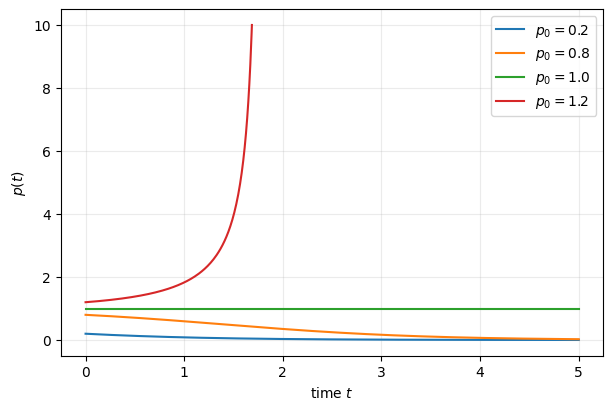

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import root

beta = 1.0
gamma = 1.0

def rhs(t, y):
    p = y[0]
    return [beta*p**2 - gamma*p]

def large_p(t, y):
    return 10.0 - y[0]

large_p.terminal = True
large_p.direction = -1

p0_values = [0.2, 0.8, 1.0, 1.2]
numerical_solutions = {}

plt.figure(figsize=(7, 4.5))
for p0 in p0_values:
    sol = solve_ivp(
        rhs, (0, 5), [p0],
        dense_output=True,
        max_step=0.01,
        events=large_p,
        rtol=1e-9,
        atol=1e-11,
    )
    numerical_solutions[p0] = sol
    plt.plot(sol.t, sol.y[0], label=fr"$p_0={p0}$")

plt.xlabel("time $t$")
plt.ylabel("$p(t)$")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

Trajectories with $p_0<1$ decay towards $0$, $p_0=1$ remains at an
equilibrium, and $p_0>1$ grows rapidly.

### (b) Comparison with the analytical solution

For $\beta=\gamma=1$, the analytical solution from Question 2 is
$$
p(t)=\frac{p_0}{p_0+(1-p_0)e^t}.
$$

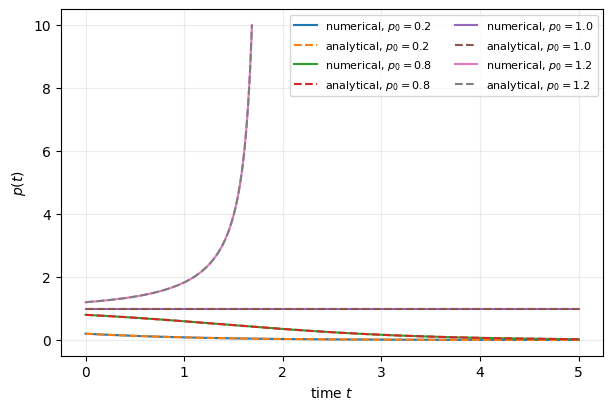

In [2]:
def p_analytical(t, p0):
    return p0 / (p0 + (1.0 - p0)*np.exp(t))

plt.figure(figsize=(7, 4.5))
for p0, sol in numerical_solutions.items():
    plt.plot(sol.t, sol.y[0], label=fr"numerical, $p_0={p0}$")
    t_dense = np.linspace(sol.t[0], sol.t[-1], 500)
    plt.plot(
        t_dense, p_analytical(t_dense, p0), "--",
        label=fr"analytical, $p_0={p0}$"
    )

plt.xlabel("time $t$")
plt.ylabel("$p(t)$")
plt.legend(ncol=2, fontsize=8)
plt.grid(True, alpha=0.25)
plt.show()

The numerical and analytical trajectories agree up to numerical accuracy,
until the growing trajectory approaches its finite-time singularity.

### (c) Numerical equilibria

In [3]:
guesses = [0.05, 0.25, 0.75, 1.25, 2.0]
equilibria = []

for guess in guesses:
    sol = root(lambda z: beta*z[0]**2 - gamma*z[0], [guess])
    if sol.success and sol.x[0] >= -1e-8:
        r = float(sol.x[0])
        if not any(abs(r-r0) < 1e-6 for r0 in equilibria):
            equilibria.append(r)

equilibria = sorted(equilibria)
print("Equilibria:", equilibria)

Equilibria: [0.0, 1.0]


The numerical roots are
$$
p_1^\star=0,\qquad p_2^\star=1,
$$
in agreement with the analytical equilibria from Question 2.

### (d) Stability from perturbed simulations

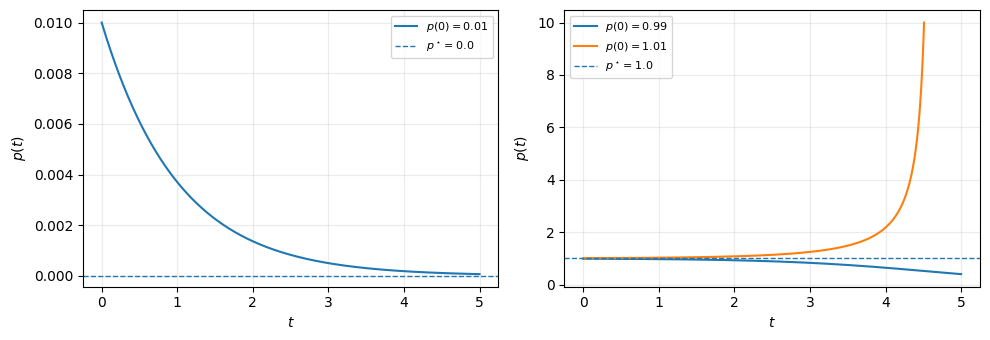

In [4]:
eps = 1e-2

fig, axes = plt.subplots(1, len(equilibria), figsize=(10, 3.5))
if len(equilibria) == 1:
    axes = [axes]

for ax, pstar in zip(axes, equilibria):
    for perturbation in [-eps, eps]:
        p_init = pstar + perturbation
        # Avoid a negative concentration when perturbing p*=0.
        if p_init < 0:
            continue
        sol = solve_ivp(
            rhs, (0, 5), [p_init],
            max_step=0.01,
            events=large_p,
            rtol=1e-9,
            atol=1e-11,
        )
        ax.plot(sol.t, sol.y[0], label=fr"$p(0)={p_init:.2f}$")
    ax.axhline(pstar, linestyle="--", linewidth=1, label=fr"$p^\star={pstar:.1f}$")
    ax.set_xlabel("$t$")
    ax.set_ylabel("$p(t)$")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

Perturbations near $p^\star=0$ return towards zero, so $p^\star=0$ is
stable. Immediately below $p^\star=1$, trajectories move towards zero;
immediately above it, they move away and grow. Hence $p^\star=1$ is
unstable.

### (e) Finite-time blow-up for $p_0=1.2$

A numerical integrator cannot reach infinity. We therefore stop the
trajectory at successively larger thresholds and inspect the event times.

In [5]:
def threshold_event(level):
    def event(t, y):
        return level - y[0]
    event.terminal = True
    event.direction = -1
    return event

p0 = 1.2
thresholds = [10, 100, 1000, 10000]
event_times = []

for level in thresholds:
    sol = solve_ivp(
        rhs, (0, 3), [p0],
        events=threshold_event(level),
        rtol=1e-10,
        atol=1e-12,
        max_step=1e-3,
    )
    t_event = sol.t_events[0][0]
    event_times.append(t_event)
    print(f"p = {level:5g}: t = {t_event:.6f}")

t_blowup = np.log(p0/(p0-1.0))
print(f"\nAnalytical blow-up time: {t_blowup:.6f}")

p =    10: t = 1.686399
p =   100: t = 1.781709


p =  1000: t = 1.790759
p = 10000: t = 1.791659

Analytical blow-up time: 1.791759


The threshold-crossing times approach
$$
t_{\mathrm b}
=\ln\left(\frac{p_0}{p_0-1}\right)
=\ln(6)
\approx 1.792,
$$
as the threshold is increased.